In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.shape

(891, 12)

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.drop('Cabin', axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
print("Sex categories:")
print(df['Sex'].value_counts())

print("\nEmbarked categories:")
print(df['Embarked'].value_counts())

Sex categories:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked categories:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
df = pd.get_dummies(df, columns=['Embarked'], dtype=int)

In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked_C,int64
Embarked_Q,int64
Embarked_S,int64


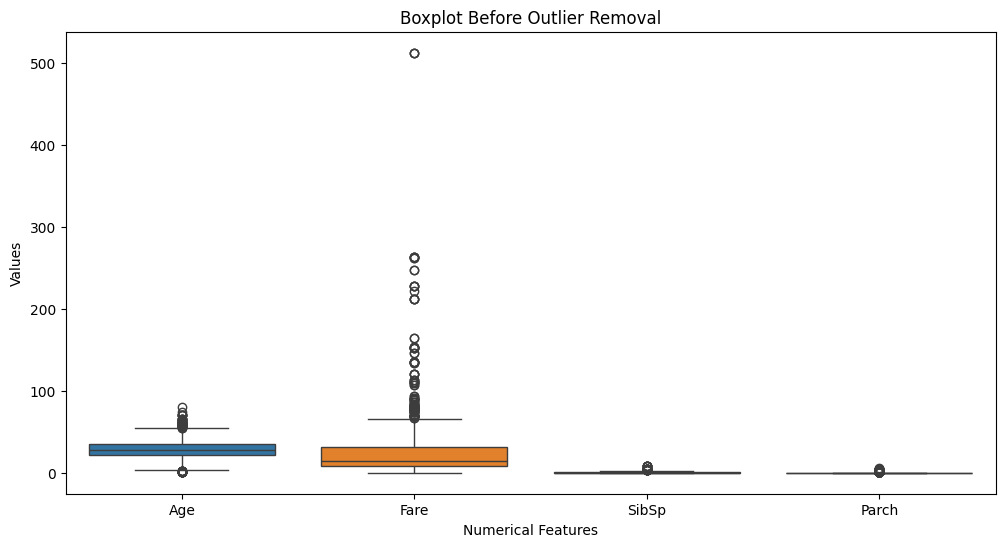

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[['Age', 'Fare', 'SibSp', 'Parch']])

plt.title('Boxplot Before Outlier Removal')
plt.xlabel('Numerical Features')
plt.ylabel('Values')
plt.show()

In [ ]:
outlier_columns = ['Age', 'Fare']

Q1 = df[outlier_columns].quantile(0.25)
Q3 = df[outlier_columns].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limits:")
print(lower_limit)

print("\nUpper limits:")
print(upper_limit)

Lower limits:
Age      2.500
Fare   -26.724
dtype: float64

Upper limits:
Age     54.5000
Fare    65.6344
dtype: float64


In [ ]:
outlier_mask = (
    (df[outlier_columns] >= lower_limit) &
    (df[outlier_columns] <= upper_limit)
).all(axis=1)

df = df[outlier_mask].copy()

print("Dataset shape after outlier removal:", df.shape)

Dataset shape after outlier removal: (721, 10)


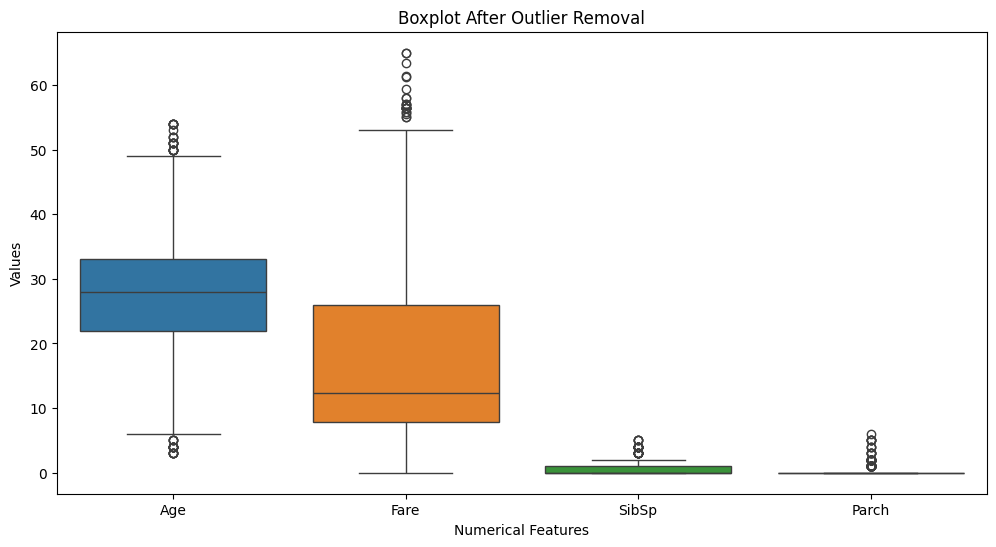

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[['Age', 'Fare', 'SibSp', 'Parch']])

plt.title('Boxplot After Outlier Removal')
plt.xlabel('Numerical Features')
plt.ylabel('Values')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
features_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']

In [ ]:
scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [ ]:
df[features_to_scale].describe()

,Age,Fare,SibSp,Parch
count,7.210000e+02,7.210000e+02,7.210000e+02,7.210000e+02
mean,-1.872443e-16,5.420229e-17,-9.854962e-18,-6.282538e-17
std,1.000694e+00,1.000694e+00,1.000694e+00,1.000694e+00
min,-2.505671e+00,-1.283040e+00,-4.859842e-01,-4.101032e-01
25%,-6.085180e-01,-7.004801e-01,-4.859842e-01,-4.101032e-01
50%,-9.417211e-03,-3.773784e-01,-4.859842e-01,-4.101032e-01
75%,4.898335e-01,6.352657e-01,6.859042e-01,-4.101032e-01
max,2.586686e+00,3.512724e+00,5.373458e+00,7.204088e+00


In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.608518,0.685904,-0.410103,-0.748128,0,0,1
2,1,3,1,-0.209117,-0.485984,-0.410103,-0.698326,0,0,1
3,1,1,1,0.689534,0.685904,-0.410103,2.634730,0,0,1
4,0,3,0,0.689534,-0.485984,-0.410103,-0.689103,0,0,1
5,0,3,0,-0.009417,-0.485984,-0.410103,-0.658978,0,1,0


In [ ]:
print("Final dataset shape:", df.shape)

Final dataset shape: (721, 10)


In [ ]:
print("Missing values in final dataset:")
print(df.isnull().sum())

Missing values in final dataset:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,float64
SibSp,float64
Parch,float64
Fare,float64
Embarked_C,int64
Embarked_Q,int64
Embarked_S,int64


In [ ]:
df.to_csv('/content/Titanic_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


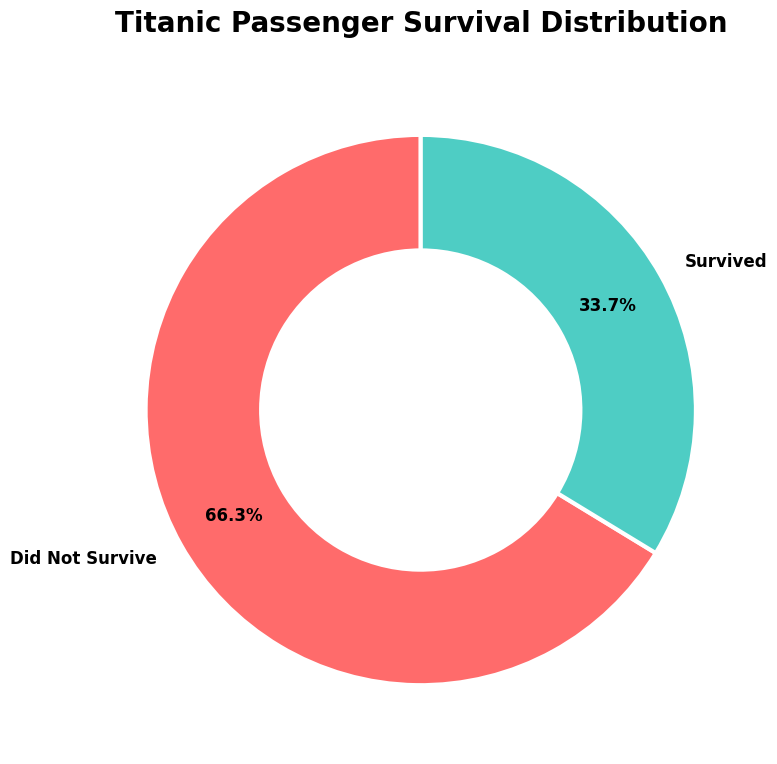

In [107]:


survival_counts = df['Survived'].value_counts().sort_index()

labels = ['Did Not Survive', 'Survived']
values = survival_counts.values

colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(8, 8))

plt.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={
        'width': 0.42,
        'edgecolor': 'white',
        'linewidth': 3
    }
)

plt.title(
    'Titanic Passenger Survival Distribution',
    fontsize=20,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.show()